# Explicabilidad del Modelo

## Objetivo

El objetivo de este notebook es analizar e interpretar el comportamiento del modelo final utilizado para estimar la probabilidad de compra (`Revenue`).

La explicabilidad se aborda desde dos perspectivas:

- **Explicabilidad global:** identificar qué variables tienen mayor influencia en las predicciones del modelo.
- **Explicabilidad local:** analizar qué variables contribuyen a aumentar o disminuir la probabilidad estimada de compra para una sesión particular.

Para ello se utilizarán técnicas de **Feature Importance** y **SHAP (SHapley Additive exPlanations)**.

Este análisis complementa las métricas tradicionales de evaluación y permite comprender no solo qué tan bien predice el modelo, sino también qué señales utiliza para tomar sus decisiones.

In [27]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

In [28]:
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = DATA_DIR / "models"

print("Proyecto:", PROJECT_ROOT)
print("\nModelos disponibles:")

for archivo in MODELS_DIR.glob("*"):
    print("-", archivo.name)

Proyecto: c:\Users\Lucas\OneDrive\Desktop\Proyecto Final

Modelos disponibles:
- .gitkeep
- mejores_hiperparametros.json
- modelo_final.joblib
- preprocessor.joblib
- train_test_split.joblib


In [29]:
modelo = joblib.load(MODELS_DIR / "modelo_final.joblib")
preprocessor = joblib.load(MODELS_DIR / "preprocessor.joblib")
split = joblib.load(MODELS_DIR / "train_test_split.joblib")

X_train = split["X_train"]
X_test = split["X_test"]
y_train = split["y_train"]
y_test = split["y_test"]

print("Tipo de modelo final:")
print(type(modelo))

print("\nShape train:", X_train.shape)
print("Shape test:", X_test.shape)

Tipo de modelo final:
<class 'sklearn.calibration.CalibratedClassifierCV'>

Shape train: (9764, 78)
Shape test: (2441, 78)


In [30]:
feature_names = preprocessor.get_feature_names_out()

print("Cantidad de features:", len(feature_names))
print("\nPrimeras 20:")
for nombre in feature_names[:20]:
    print(nombre)

Cantidad de features: 78

Primeras 20:
num__Administrative
num__Administrative_Duration
num__Informational
num__Informational_Duration
num__ProductRelated
num__ProductRelated_Duration
num__BounceRates
num__ExitRates
num__PageValues
num__SpecialDay
num__duracion_total
num__paginas_totales
num__duracion_promedio_pagina
num__proporcion_paginas_producto
num__Weekend
num__es_visitante_recurrente
cat__Month_Aug
cat__Month_Dec
cat__Month_Feb
cat__Month_Jul


In [31]:
print("Cantidad de modelos calibrados:")
print(len(modelo.calibrated_classifiers_))

for i, calibrado in enumerate(modelo.calibrated_classifiers_):
    print(
        f"Fold {i + 1}:",
        type(calibrado.estimator)
    )

Cantidad de modelos calibrados:
3
Fold 1: <class 'lightgbm.sklearn.LGBMClassifier'>
Fold 2: <class 'lightgbm.sklearn.LGBMClassifier'>
Fold 3: <class 'lightgbm.sklearn.LGBMClassifier'>


In [32]:
import pandas as pd
import numpy as np

importancias_folds = []

for i, calibrado in enumerate(modelo.calibrated_classifiers_):
    estimador = calibrado.estimator
    
    importancia = pd.DataFrame({
        "feature": feature_names,
        "importance": estimador.feature_importances_,
        "fold": i + 1
    })
    
    importancias_folds.append(importancia)

df_importancias = pd.concat(importancias_folds, ignore_index=True)

feature_importance = (
    df_importancias
    .groupby("feature", as_index=False)["importance"]
    .mean()
    .sort_values("importance", ascending=False)
)

feature_importance.head(15)

,feature,importance
68,num__PageValues,680.333333
65,num__ExitRates,583.000000
77,num__proporcion_paginas_producto,490.666667
64,num__BounceRates,338.333333
20,cat__Month_Nov,315.333333
76,num__paginas_totales,303.666667
19,cat__Month_May,298.333333
70,num__ProductRelated_Duration,279.666667
74,num__duracion_total,267.000000
63,num__Administrative_Duration,241.000000


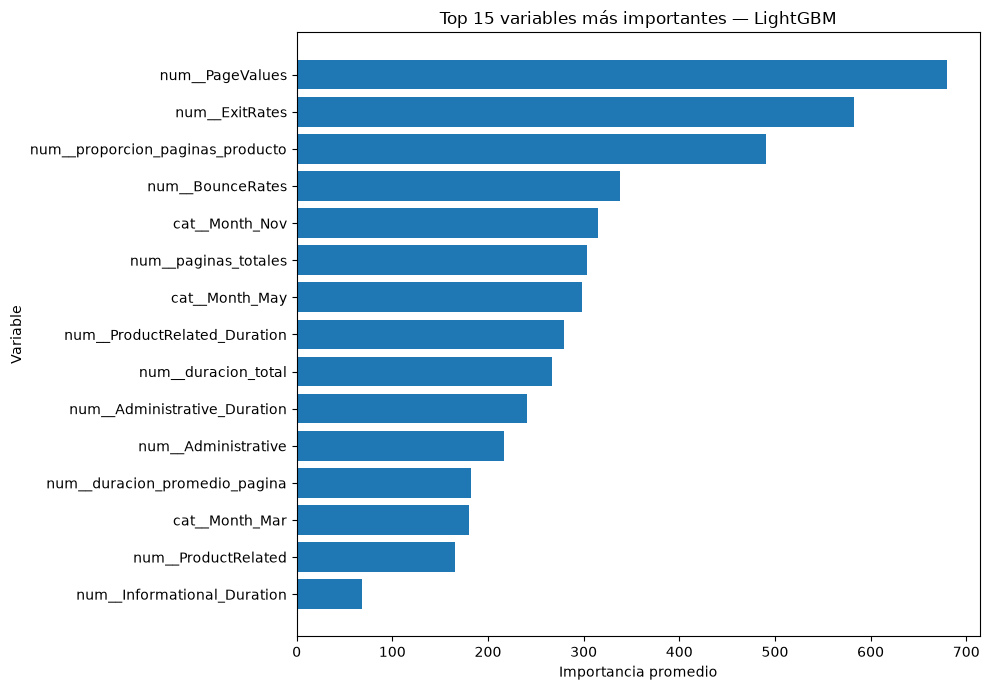

In [33]:
top_n = 15

top_features = feature_importance.head(top_n).sort_values(
    "importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.title("Top 15 variables más importantes — LightGBM")
plt.xlabel("Importancia promedio")
plt.ylabel("Variable")
plt.tight_layout()

plt.show()

In [34]:
feature_importance["feature_limpia"] = (
    feature_importance["feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

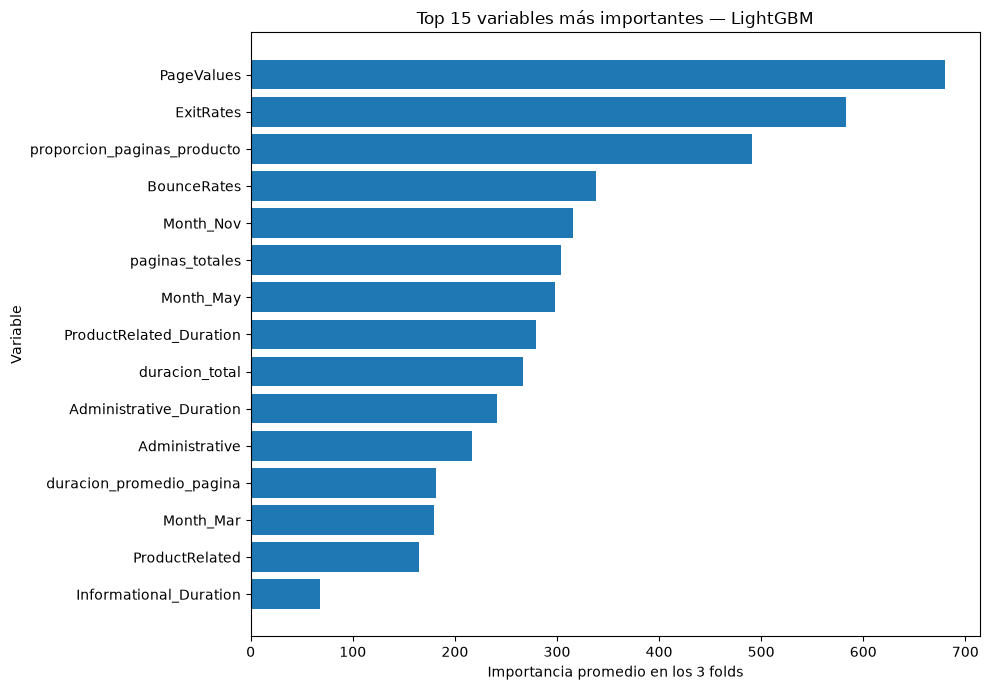

In [35]:
top_features = (
    feature_importance
    .head(15)
    .sort_values("importance", ascending=True)
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["feature_limpia"],
    top_features["importance"]
)

plt.title("Top 15 variables más importantes — LightGBM")
plt.xlabel("Importancia promedio en los 3 folds")
plt.ylabel("Variable")
plt.tight_layout()

plt.show()

## Feature Importance

Como el modelo final utiliza `CalibratedClassifierCV` con validación cruzada de 3 folds, existen tres estimadores LightGBM internos.

Para obtener una medida global más robusta, se calcula la importancia de cada variable en los tres estimadores y se utiliza el promedio como importancia global.

Este análisis permite identificar qué variables son utilizadas con mayor frecuencia por el modelo para realizar sus divisiones y construir las predicciones.

Sin embargo, la Feature Importance no indica por sí sola la dirección del efecto de cada variable. Para complementar este análisis se utilizarán posteriormente valores SHAP.

In [36]:
estimador_shap = modelo.calibrated_classifiers_[0].estimator

print(type(estimador_shap))

<class 'lightgbm.sklearn.LGBMClassifier'>


In [37]:
explainer = shap.TreeExplainer(estimador_shap)

shap_values = explainer(X_test)

print("Shape X_test:", X_test.shape)
print("Shape SHAP:", shap_values.values.shape)

Shape X_test: (2441, 78)
Shape SHAP: (2441, 78)


In [38]:
feature_names_limpios = [
    nombre
    .replace("num__", "")
    .replace("cat__", "")
    for nombre in feature_names
]

shap_values.feature_names = feature_names_limpios

## Explicabilidad mediante SHAP

La importancia de variables permite identificar qué características son utilizadas con mayor intensidad por el modelo, pero no permite conocer la dirección de su efecto sobre las predicciones.

Para profundizar el análisis se utilizan valores **SHAP (SHapley Additive exPlanations)**, que permiten estimar la contribución individual de cada variable sobre la salida del modelo.

El análisis se realiza sobre uno de los estimadores LightGBM internos del modelo calibrado. La calibración posterior transforma el score generado por el modelo base en una probabilidad de compra más fiable.

Se utilizan dos visualizaciones complementarias:

- **SHAP Bar Plot:** muestra la magnitud promedio del impacto de cada variable.
- **SHAP Beeswarm Plot:** muestra tanto la magnitud como la dirección del impacto y su relación con valores altos o bajos de cada característica.

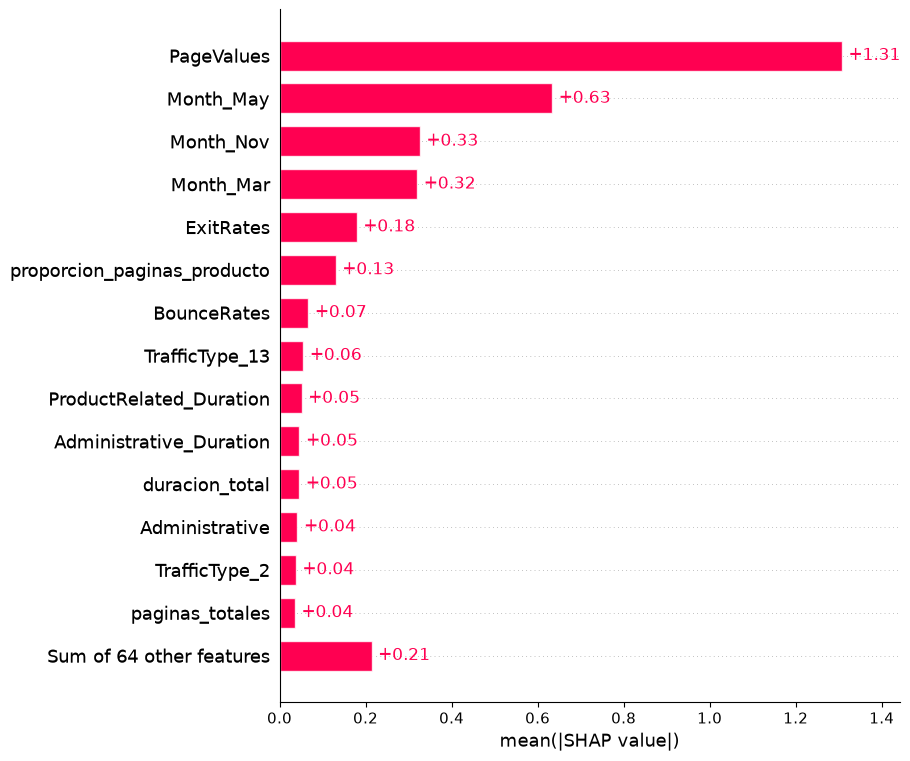

In [39]:
shap.plots.bar(
    shap_values,
    max_display=15
)
#¿Qué variables tienen mayor impacto promedio sobre las predicciones?

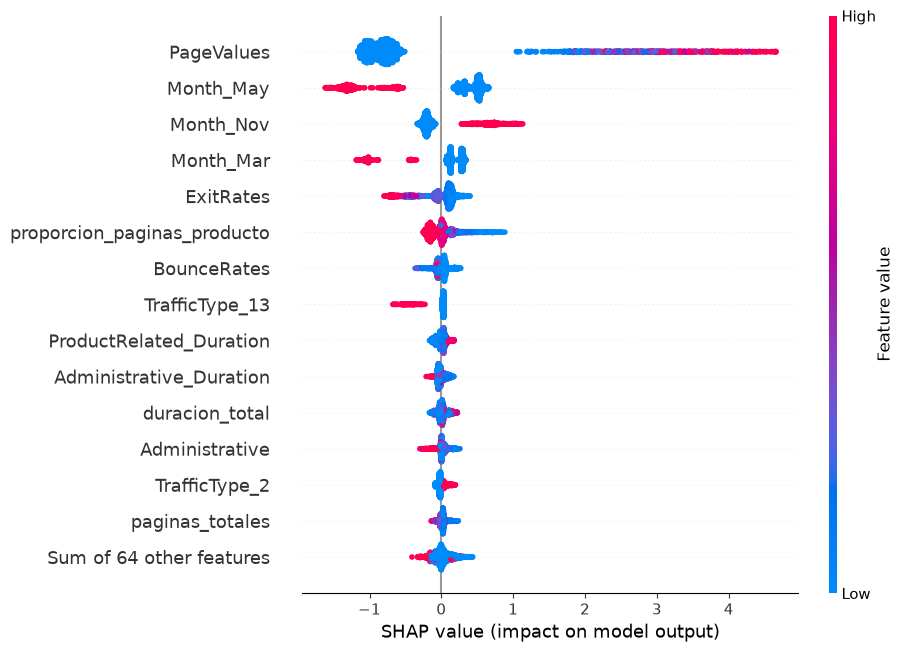

In [40]:
shap.plots.beeswarm(
    shap_values,
    max_display=15
)
#¿Qué variables importan?
#¿Cómo influyen sus valores sobre la predicción?

### Principales hallazgos

El análisis SHAP confirma que **PageValues** es la variable con mayor influencia sobre las predicciones del modelo, presentando una diferencia considerable respecto del resto de las características.

Los valores elevados de `PageValues` se concentran principalmente en valores SHAP positivos, indicando que una mayor valoración económica de las páginas visitadas tiende a incrementar el score de compra estimado por el modelo. Por el contrario, valores bajos de esta variable presentan principalmente contribuciones negativas.

También se observa una influencia relevante de variables temporales. En particular, `Month_May`, `Month_Nov` y `Month_Mar` presentan impactos diferenciados, lo que indica que el modelo ha capturado patrones estacionales asociados al comportamiento de compra.

En el caso de `ExitRates`, los valores elevados tienden a generar contribuciones negativas, mientras que valores bajos se concentran alrededor de contribuciones neutras o positivas. Esto resulta consistente con la interpretación de esta variable como una señal asociada al abandono de la sesión.

La variable derivada `proporcion_paginas_producto`, construida durante la etapa de Feature Engineering, también presenta una influencia relevante. Esto aporta evidencia de que las características diseñadas durante el proyecto agregan información útil al modelo más allá de las variables originales.

En conjunto, los resultados muestran que el modelo combina señales de **valor comercial de la navegación, comportamiento de abandono, interacción con productos y estacionalidad** para estimar la propensión de compra.

In [41]:
probabilidades_test = modelo.predict_proba(X_test)[:, 1]

idx_alta = np.argmax(probabilidades_test)

print("Índice seleccionado:", idx_alta)
print(
    "Probabilidad calibrada de compra:",
    round(probabilidades_test[idx_alta], 4)
)
print(
    "Clase real:",
    y_test.iloc[idx_alta] if hasattr(y_test, "iloc") else y_test[idx_alta]
)

Índice seleccionado: 982
Probabilidad calibrada de compra: 0.944
Clase real: 1


In [42]:
explicacion_alta = shap_values[idx_alta]

print("Sesión seleccionada:")
print("Probabilidad:", round(probabilidades_test[idx_alta], 4))

Sesión seleccionada:
Probabilidad: 0.944


## Explicabilidad local

Además del comportamiento global del modelo, SHAP permite analizar predicciones individuales.

Para ejemplificar este enfoque se selecciona una sesión del conjunto de test con alta propensión de compra.

El Waterfall Plot muestra cómo cada característica contribuye a modificar la salida del modelo respecto de su valor base:

- Las contribuciones positivas aumentan el score estimado de compra.
- Las contribuciones negativas reducen el score.
- La combinación de todas las contribuciones determina la salida final del estimador LightGBM.

La probabilidad utilizada por el sistema productivo se obtiene posteriormente mediante la calibración del modelo.

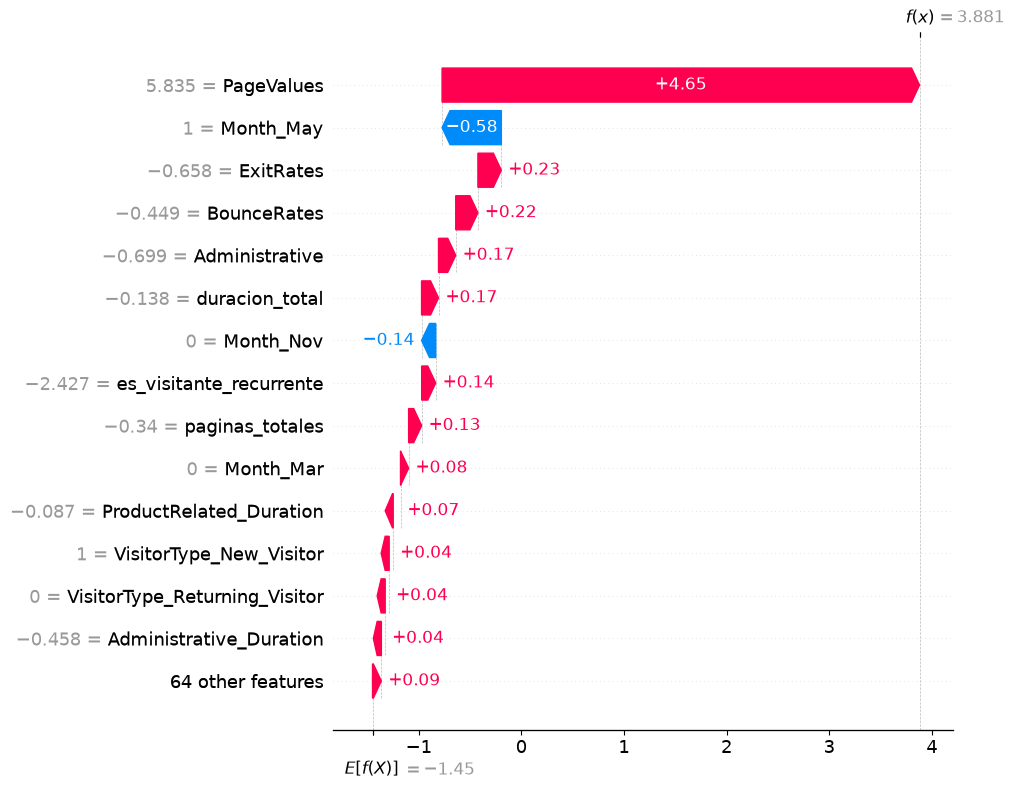

In [43]:
shap.plots.waterfall(
    explicacion_alta,
    max_display=15
)

In [44]:
idx_baja = np.argmin(probabilidades_test)

print("Índice seleccionado:", idx_baja)
print(
    "Probabilidad calibrada de compra:",
    round(probabilidades_test[idx_baja], 4)
)
print(
    "Clase real:",
    y_test.iloc[idx_baja] if hasattr(y_test, "iloc") else y_test[idx_baja]
)

Índice seleccionado: 412
Probabilidad calibrada de compra: 0.0006
Clase real: 0


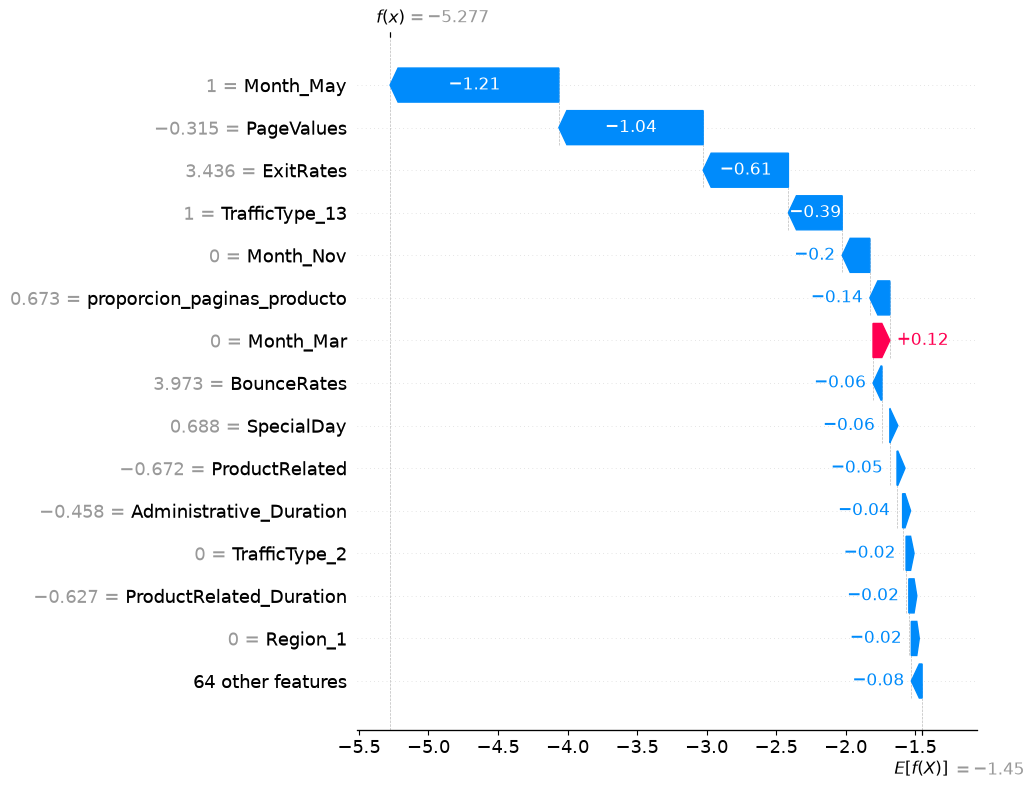

In [45]:
explicacion_baja = shap_values[idx_baja]

shap.plots.waterfall(
    explicacion_baja,
    max_display=15
)

### Interpretación de predicciones individuales

Los casos analizados muestran cómo el modelo puede alcanzar predicciones diferentes a partir de la combinación de múltiples señales de navegación.

#### Sesión de alta propensión

En la sesión seleccionada con alta propensión de compra, `PageValues` constituye la principal contribución positiva al score del modelo, con un impacto considerablemente superior al resto de las variables.

Aunque algunas características generan contribuciones negativas, su efecto no resulta suficiente para compensar la fuerte señal positiva asociada al valor comercial de las páginas visitadas.

Este comportamiento es consistente con el análisis global realizado previamente, donde `PageValues` fue identificada como la característica de mayor importancia tanto mediante Feature Importance como mediante SHAP.

#### Sesión de baja propensión

En la sesión de baja propensión se observa el comportamiento opuesto. Variables como `Month_May`, `PageValues`, `ExitRates` y determinadas fuentes de tráfico generan contribuciones negativas que reducen conjuntamente el score estimado por el modelo.

Esto evidencia que el modelo no basa sus decisiones en una única característica, sino que combina señales relacionadas con el valor de navegación, abandono, temporalidad, tráfico e interacción con productos.

> **Nota:** los valores mostrados para las variables numéricas corresponden al espacio transformado por el pipeline de preprocesamiento, por lo que algunas variables se encuentran estandarizadas. Los valores SHAP explican la salida del estimador LightGBM interno; posteriormente, el sistema aplica calibración para obtener la probabilidad final utilizada por la API.

## Conclusiones

El análisis de explicabilidad permitió comprender tanto el comportamiento global como las decisiones individuales del modelo de propensión de compra.

Los principales resultados son:

1. **PageValues es la señal dominante del modelo.**  
   Tanto Feature Importance como SHAP la identifican como la variable de mayor impacto sobre las predicciones.

2. **Las señales de abandono aportan información relevante.**  
   Variables como `ExitRates` y `BounceRates` presentan una influencia significativa y permiten capturar comportamientos asociados a la salida de una sesión.

3. **El modelo identifica patrones temporales.**  
   Variables asociadas al mes de navegación presentan impactos relevantes, evidenciando la existencia de patrones estacionales en el comportamiento de compra.

4. **La Ingeniería de Características aporta información útil.**  
   Variables derivadas como `proporcion_paginas_producto`, `paginas_totales` y `duracion_total` aparecen entre las características relevantes, respaldando las decisiones tomadas durante Feature Engineering.

5. **Las predicciones individuales son interpretables.**  
   Los valores SHAP permiten identificar qué señales aumentan o disminuyen el score para una sesión particular, evitando tratar al modelo únicamente como una caja negra.

En conjunto, estos resultados permiten complementar las métricas predictivas con evidencia sobre el funcionamiento interno del modelo y proporcionan una base interpretable para conectar la predicción de propensión con las reglas del Motor de Prescripción.